# Review NLP Analysis
### Analysis for Revolut, Klarna and Wise mobile app reviews

Loads `data/reviews_all.csv` (the combined scrape output), cleans the review text, scores sentiment
with **VADER**, and tags each review into functional product-issue buckets (KYC/Onboarding, Card
Declines, Transfer Latency, UI/UX Bug, Customer Support Friction, and a few more) using a rule-based
keyword classifier.

**Environment.** Run with the `strategic-moat` kernel (same venv as the scraper notebook):
```bash
.venv/bin/pip install vaderSentiment
```

In [1]:
import html
import os
import re

import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

pd.set_option("display.max_colwidth", 100)

DATA_DIR = "data"
IN_PATH  = os.path.join(DATA_DIR, "reviews_all.csv")
OUT_PATH = os.path.join(DATA_DIR, "reviews_analyzed.csv")

## 1. Load reviews

Pulls `content` (the review text), rating, app, platform and timestamp out of the combined scrape
output. Rows with no text at all are dropped up front — VADER and the keyword tagger both need text
to work with.

In [2]:
df = pd.read_csv(IN_PATH)
df["reviewed_at"] = pd.to_datetime(df["reviewed_at"], utc=True, errors="coerce")

before = len(df)
df = df.dropna(subset=["content"]).copy()
df = df[df["content"].str.strip().str.len() > 0].copy()
print(f"Loaded {before} rows, {len(df)} have non-empty review text")

df[["platform", "app", "score", "content"]].head()

Loaded 20007 rows, 20007 have non-empty review text


,platform,app,score,content
0,google_play,Revolut,5,great app
1,google_play,Revolut,4,excellent
2,google_play,Revolut,5,"Been using for many years, great experience till now, everything is easy to setup and convenient"
3,google_play,Revolut,1,blocked account without any explanation after 9 years of usage
4,google_play,Revolut,5,great app.


## 2. Clean review text

Strips the noise that isn't sentiment- or topic-bearing: HTML entities (`&amp;` etc., which the iOS
RSS feed sometimes leaves in), URLs, emoji, and repeated whitespace. Case and punctuation are
otherwise left alone — VADER uses capitalization ("AWFUL") and punctuation ("!!!") as intensity
signals, so lowercasing before scoring would throw away information.

Rows that clean down to nothing (pure emoji, a stray URL, "...") are dropped as noise.

In [3]:
URL_RE   = re.compile(r"http\S+|www\.\S+")
HTML_RE  = re.compile(r"<[^>]+>")
EMOJI_RE = re.compile(
    "["
    "\U0001F300-\U0001FAFF"   # symbols, pictographs, emoticons, transport
    "\U00002600-\U000027BF"   # misc symbols & dingbats
    "\U0001F1E6-\U0001F1FF"   # regional indicators (flags)
    "\U00002190-\U000021FF"   # arrows
    "\U00002B00-\U00002BFF"   # misc symbols/arrows
    "]+",
    flags=re.UNICODE,
)
WS_RE = re.compile(r"\s+")


def clean_text(text):
    if not isinstance(text, str):
        return ""
    t = html.unescape(text)
    t = URL_RE.sub(" ", t)
    t = HTML_RE.sub(" ", t)
    t = EMOJI_RE.sub(" ", t)
    t = WS_RE.sub(" ", t).strip()
    return t


df["clean_content"] = df["content"].map(clean_text)

before = len(df)
df = df[df["clean_content"].str.contains(r"[A-Za-z0-9]", regex=True, na=False)].copy()
df = df.reset_index(drop=True)
print(f"Dropped {before - len(df)} rows that cleaned down to no real text; {len(df)} remain")

df[["content", "clean_content"]].sample(5, random_state=0)

Dropped 146 rows that cleaned down to no real text; 19861 remain


,content,clean_content
8368,"It's such an amazing way to control money. zero interest helps a lot. I love using klarna, it ha...","It's such an amazing way to control money. zero interest helps a lot. I love using klarna, it ha..."
8755,It can be helpful for you to split up the payments when you have no where near the amount you ne...,It can be helpful for you to split up the payments when you have no where near the amount you ne...
7898,amazing,amazing
19116,Love Klarna | Give freedom spread my payment help with my money,Love Klarna | Give freedom spread my payment help with my money
17642,Best and fastest FX app on the market.,Best and fastest FX app on the market.


## 3. VADER sentiment scoring

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon/rule-based sentiment model tuned
for short, informal text — a good fit for app store reviews. For each review it returns `neg`/`neu`/`pos`
proportions and a single normalized `compound` score in `[-1, 1]`.

Reviews are labeled using VADER's own documented thresholds: `compound >= 0.05` → positive,
`compound <= -0.05` → negative, otherwise neutral.

In [4]:
analyzer = SentimentIntensityAnalyzer()

vader_scores = pd.DataFrame(list(df["clean_content"].apply(analyzer.polarity_scores)))
vader_scores = vader_scores.add_prefix("vader_").reset_index(drop=True)
df = pd.concat([df.reset_index(drop=True), vader_scores], axis=1)


def label_sentiment(compound):
    if compound >= 0.05:
        return "positive"
    if compound <= -0.05:
        return "negative"
    return "neutral"


df["vader_sentiment"] = df["vader_compound"].map(label_sentiment)

print(df["vader_sentiment"].value_counts())
print("\nMean compound score by star rating:")
print(df.groupby("score", observed=True)["vader_compound"].mean().round(3))

vader_sentiment
positive    14560
negative     2840
neutral      2461
Name: count, dtype: int64

Mean compound score by star rating:
score
1   -0.178
2   -0.038
3    0.104
4    0.378
5    0.548
Name: vader_compound, dtype: float64


## 4. Categorize into functional product buckets

There's no labeled training set here, so categorization is a transparent **rule-based keyword/phrase
classifier** rather than a trained model: each bucket is a set of regex patterns tuned to how people
actually phrase these complaints in fintech app reviews (e.g. "card declined", "still hasn't arrived",
"account frozen").

A review can match **multiple** buckets (a review can complain about both a card decline and slow
support). `categories` holds every bucket that matched; `primary_category` picks one for simple
grouping, using the fixed priority order below (harder operational failures — being locked out of your
money entirely — rank above softer ones like a UI bug). Reviews matching no complaint bucket fall back
to **General Praise** (high score + clearly positive sentiment, e.g. "great app", "excellent") or
**Uncategorized**.

Buckets, in priority order:
1. **Account Freeze/Restriction** — account or funds frozen, locked, restricted, closed
2. **Card Declines** — card/payment/transaction declined or blocked
3. **Transfer Latency** — money/transfers stuck, pending, slow to arrive
4. **KYC/Onboarding** — identity verification, document rejection, sign-up friction
5. **Login/Access Issues** — can't log in, 2FA, biometrics, password reset
6. **Customer Support Friction** — unresponsive/unhelpful support, chatbot loops, no way to reach a human
7. **Fees/Pricing** — hidden fees, poor exchange rates, overcharging
8. **UI/UX Bug** — crashes, glitches, broken screens, bad redesigns

In [5]:
# Priority order: index = tie-break rank used by primary_category() below.
#
# Each bucket generally needs BOTH word orders for its key verb/noun pair — reviewers phrase
# complaints either way ("account is locked" vs. "they locked my account", "card declined" vs.
# "keeps declining my card") — so patterns are duplicated in both directions rather than relying
# on one canonical phrasing.
CATEGORY_KEYWORDS = {
    "Account Freeze/Restriction": [
        r"account (was |is |got |been )?(frozen|freeze|locked|restrict\w*|suspend\w*|clos\w*|block\w*)",
        r"(lock\w*|froze|frozen|clos\w*|restrict\w*|suspend\w*|block\w*) (my |your |the )?account",
        r"funds? (are|were|is|got|being) (frozen|locked|held|on hold)",
        r"blocked (my|the) account",
        r"locked (me )?out of my account",
        r"restricted my account",
        r"can.?t access my (money|funds|account)",
    ],
    "Card Declines": [
        r"card (was |is |keeps |got )?declin\w*",
        r"(payment|transaction|purchase) (was |is |keeps |got )?declin\w*",
        r"declin\w* (my |your |the )?(scheduled )?(card|payment|transaction|purchase)",
        r"card (isn.?t|is not|not) working",
        r"card (got |was )?block\w*",
        r"(block\w*|froze|frozen) (my |your |the )?(debit |credit )?card",
        r"declined (my |the )?(card|payment|transaction)",
        r"card (got |was )?rejected",
        r"contactless (isn.?t|not) working",
    ],
    "Transfer Latency": [
        r"transfer\w* (is |was |still |has been )?(pending|stuck|delayed|taking)",
        r"money (is |was |got )?stuck",
        r"still (hasn.?t|has not) arrived",
        r"(never|still) (arrived|made it|shown up|showed up|come through|gone through)",
        r"days? to (arrive|clear|process)",
        r"withdrawal (is |was )?pending",
        r"waiting (for|on) my money",
        r"slow (transfer|to transfer)",
        r"transfer (didn.?t|did not|never) (arrive|complete|go through)",
        r"pending for (days|weeks)",
    ],
    "KYC/Onboarding": [
        r"verif\w* (my |the )?(identity|account|document)",
        r"\bkyc\b",
        r"identity check",
        r"id document",
        r"\bselfie\b",
        r"proof of address",
        r"onboard\w*",
        r"sign ?up (process|was|is)",
        r"couldn.?t open (an |my )?account",
        r"documents? (were |was )?rejected",
    ],
    "Login/Access Issues": [
        r"can.?t log ?in",
        r"login (failed|error|issue|problem)",
        r"(logged|kicked) (me )?out",
        r"two.?factor",
        r"\b2fa\b",
        r"password reset",
        r"pin (isn.?t|not) working",
        r"face ?id (isn.?t|not) working",
        r"biometric\w*",
    ],
    "Customer Support Friction": [
        r"customer (service|support)",
        r"support team",
        r"no response",
        r"can.?t reach (anyone|support|them)",
        r"\bchatbot\b",
        r"live chat",
        r"waited (days|weeks|hours)",
        r"unhelpful",
        r"no phone number",
        r"no one (replies|responds|answers)",
        r"ignored my (email|message)",
    ],
    "Fees/Pricing": [
        r"hidden fees?",
        r"charg\w* me",
        r"fees? (are|is|too|so) (high|expensive|much)",
        r"exchange rate",
        r"subscription (fee|cost)",
        r"monthly fee",
        r"overcharg\w*",
    ],
    "UI/UX Bug": [
        r"\bcrash\w*",
        r"\bbug\w*",
        r"\bglitch\w*",
        r"keeps? (crashing|freezing|glitching)",
        r"app (is |keeps )?broken",
        r"won.?t load",
        r"stopped working",
        r"update broke",
        r"blank screen",
        r"error message",
        r"force close",
    ],
}

CATEGORY_PATTERNS = {
    name: re.compile("|".join(patterns), re.IGNORECASE)
    for name, patterns in CATEGORY_KEYWORDS.items()
}


def tag_categories(text):
    return [name for name, pattern in CATEGORY_PATTERNS.items() if pattern.search(text)]


def primary_category(categories, score, compound):
    for name in CATEGORY_KEYWORDS:  # dict order = priority order
        if name in categories:
            return name
    if score >= 4 and compound >= 0.2:
        return "General Praise"
    return "Uncategorized"


df["categories"] = df["clean_content"].map(tag_categories)
df["primary_category"] = [
    primary_category(cats, score, comp)
    for cats, score, comp in zip(df["categories"], df["score"], df["vader_compound"])
]
df["n_categories"] = df["categories"].map(len)

df["primary_category"].value_counts()

primary_category
General Praise                12677
Uncategorized                  5742
Customer Support Friction       444
Fees/Pricing                    317
Account Freeze/Restriction      254
UI/UX Bug                       228
KYC/Onboarding                   89
Login/Access Issues              66
Transfer Latency                 23
Card Declines                    21
Name: count, dtype: int64

## 5. Summary — where is each app bleeding?

Restricted to the complaint buckets (excludes `General Praise` and `Uncategorized`). For each
app x category: review volume, mean VADER compound, and the negative share (`vader_sentiment ==
"negative"`) — the last column is the closest thing to a pain-point severity ranking.

In [6]:
COMPLAINT_BUCKETS = list(CATEGORY_KEYWORDS.keys())
complaints = df[df["primary_category"].isin(COMPLAINT_BUCKETS)].copy()

summary = (
    complaints.groupby(["app", "primary_category"], observed=True)
    .agg(
        n_reviews=("vader_compound", "size"),
        mean_compound=("vader_compound", "mean"),
        negative_share=("vader_sentiment", lambda s: (s == "negative").mean()),
    )
    .round(3)
    .sort_values(["app", "n_reviews"], ascending=[True, False])
)
summary

n_reviews  mean_compound  negative_share
app     primary_category                                                    
Klarna  Customer Support Friction         171         -0.067           0.561
        UI/UX Bug                          61         -0.071           0.459
        KYC/Onboarding                     32         -0.131           0.500
        Fees/Pricing                       31         -0.132           0.484
        Login/Access Issues                30          0.032           0.367
        Account Freeze/Restriction         17         -0.181           0.588
        Card Declines                      12          0.141           0.333
        Transfer Latency                    6          0.230           0.500
Revolut UI/UX Bug                         128          0.027           0.367
        Customer Support Friction         120          0.125           0.433
        Account Freeze/Restriction        101         -0.194           0.614
        Fees/Pricing                       86          0.519           0.163
        KYC/Onboarding                     28         -0.031           0.429
        Login/Access Issues                21         -0.162           0.524
        Transfer Latency                    6         -0.117           0.500
        Card Declines                       3          0.191           0.333
Wise    Fees/Pricing                      200          0.617           0.090
        Customer Support Friction         153          0.012           0.477
        Account Freeze/Restriction        136         -0.172           0.603
        UI/UX Bug                          39         -0.111           0.564
        KYC/Onboarding                     29         -0.201           0.517
        Login/Access Issues                15          0.023           0.400
        Transfer Latency                   11         -0.018           0.455
        Card Declines                       6         -0.305           0.667

In [7]:
# Same thing pivoted for a side-by-side app comparison per category
volume_pivot = pd.crosstab(complaints["primary_category"], complaints["app"])
volume_pivot["total"] = volume_pivot.sum(axis=1)
volume_pivot = volume_pivot.sort_values("total", ascending=False)
print("=== Complaint volume by category x app ===")
display(volume_pivot)

neg_share_pivot = complaints.pivot_table(
    index="primary_category", columns="app",
    values="vader_sentiment", aggfunc=lambda s: (s == "negative").mean(),
).round(3)
print("\n=== Negative-sentiment share by category x app ===")
display(neg_share_pivot.loc[volume_pivot.index])

print(f"\nMulti-label reviews (flagged with >1 category): {(df['n_categories'] > 1).sum()}")
print(f"Uncategorized (no complaint keyword match, not clearly positive): {(df['primary_category'] == 'Uncategorized').sum()}")

=== Complaint volume by category x app ===

=== Negative-sentiment share by category x app ===

Multi-label reviews (flagged with >1 category): 114
Uncategorized (no complaint keyword match, not clearly positive): 5742


app,Klarna,Revolut,Wise,total
primary_category,,,,
Customer Support Friction,171,120,153,444
Fees/Pricing,31,86,200,317
Account Freeze/Restriction,17,101,136,254
UI/UX Bug,61,128,39,228
KYC/Onboarding,32,28,29,89
Login/Access Issues,30,21,15,66
Transfer Latency,6,6,11,23
Card Declines,12,3,6,21


app,Klarna,Revolut,Wise
primary_category,,,
Customer Support Friction,0.561,0.433,0.477
Fees/Pricing,0.484,0.163,0.090
Account Freeze/Restriction,0.588,0.614,0.603
UI/UX Bug,0.459,0.367,0.564
KYC/Onboarding,0.500,0.429,0.517
Login/Access Issues,0.367,0.524,0.400
Transfer Latency,0.500,0.500,0.455
Card Declines,0.333,0.333,0.667


## 6. Save the analyzed dataset

Writes every review plus its cleaned text, VADER scores/label, and category tags to
`data/reviews_analyzed.csv`. `categories` is serialized as a `;`-joined string for CSV round-tripping.

In [8]:
out_cols = [
    "platform", "app", "review_id", "user_name", "score", "reviewed_at",
    "content", "clean_content",
    "vader_neg", "vader_neu", "vader_pos", "vader_compound", "vader_sentiment",
    "categories", "primary_category", "n_categories",
]

out_df = df[out_cols].copy()
out_df["categories"] = out_df["categories"].map(lambda cats: ";".join(cats))

out_df.to_csv(OUT_PATH, index=False)
print(f"Saved {len(out_df)} rows to {OUT_PATH}")

Saved 19861 rows to data/reviews_analyzed.csv


## 7. Chart — complaint volume by category, split by app

One measure (review count), split by category (magnitude) and app (identity) — a grouped horizontal
bar chart, one hue per app from a fixed categorical order (never cycled), sorted by total volume so the
biggest pain points read top-to-bottom.

<ipython-input-9-34458f8013e0>:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


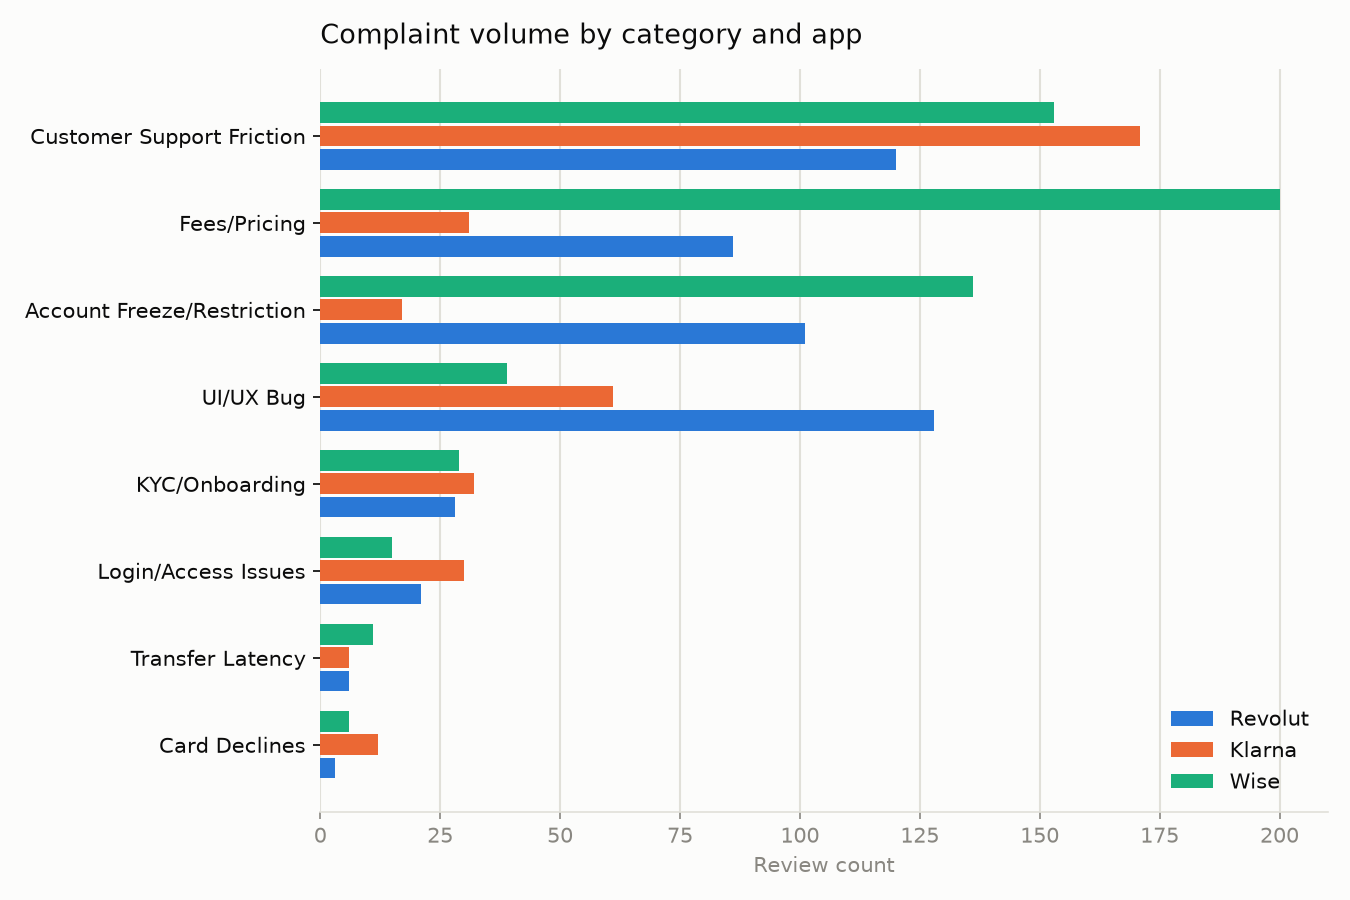

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Fixed categorical order (never cycled) — first 3 slots of the validated default palette
APP_COLORS = {"Revolut": "#2a78d6", "Klarna": "#eb6834", "Wise": "#1baf7a"}
INK        = "#0b0b0b"
MUTED      = "#898781"
GRIDLINE   = "#e1e0d9"
SURFACE    = "#fcfcfb"

apps = [a for a in APP_COLORS if a in volume_pivot.columns]
categories = volume_pivot.index.tolist()[::-1]  # reverse so highest-volume sits at top of barh
y = np.arange(len(categories))
bar_h = 0.8 / len(apps)

fig, ax = plt.subplots(figsize=(9, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for i, app in enumerate(apps):
    vals = volume_pivot.loc[categories, app].values
    offset = (i - (len(apps) - 1) / 2) * bar_h
    ax.barh(y + offset, vals, height=bar_h * 0.9, color=APP_COLORS[app], label=app)

ax.set_yticks(y)
ax.set_yticklabels(categories, color=INK, fontsize=10)
ax.set_xlabel("Review count", color=MUTED, fontsize=10)
ax.tick_params(axis="x", colors=MUTED)
ax.grid(axis="x", color=GRIDLINE, linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(GRIDLINE)

ax.set_title("Complaint volume by category and app", color=INK, fontsize=13, loc="left", pad=12)
ax.legend(loc="lower right", frameon=False, labelcolor=INK)

plt.tight_layout()
plt.show()